## Inspect

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_json('exps.jsonl', orient='records', lines=True)
df.head()

,commit,id,name,params.dataset.path,params.dataset.name,params.dataset.split,params.model.path,params.model.temperature,params.model.top_p,params.model.few_shot_prob,params.retriever.name,params.retriever.top_k,params.retriever.mode,params.run,metrics.exact_match,metrics.f1,metrics.supporting.precision,metrics.supporting.recall,metrics.supporting.f1
0,ea4878475b1d288ccfc82ea8482cab19f46bd2fe,13572ea3a1f6b39860c8c21777b1eac897aa7139,aroid-lots,bdsaglam/musique,answerable,validation,/home/baris/repos/verifiers/outputs/Llama-3.1-...,0.5,0.95,0,hybrid-tei,1,new,1,0.380637,0.488574,0.830141,0.760723,0.782274
1,ea4878475b1d288ccfc82ea8482cab19f46bd2fe,3f3fca20e6e5bc06d91d5571ee2c810c8502e93a,peppy-goos,bdsaglam/musique,answerable,validation,Qwen/Qwen2.5-7B-Instruct,0.5,0.95,0,hybrid-tei,1,new,1,0.031444,0.145499,0.815743,0.623259,0.686269
2,479d0c99b600ef8b5e33b35334d38fd070349a58,fe19afa83bebb0b52aa91bdae31998243414e3f9,woven-agas,bdsaglam/musique,answerable,validation,bdsaglam/Llama-3.1-8B-Instruct-ragent-grpo-mus...,0.5,0.95,0,hybrid-tei,1,new,1,0.286719,0.409372,0.808730,0.648083,0.701168
3,479d0c99b600ef8b5e33b35334d38fd070349a58,bac3472965c1c889eb1d8c479c7ba1df660aac28,batty-auks,bdsaglam/musique,answerable,validation,meta-llama/Llama-3.1-8B-Instruct,0.5,0.95,0,hybrid-tei,1,new,1,0.133223,0.224822,0.799703,0.660495,0.703658
4,479d0c99b600ef8b5e33b35334d38fd070349a58,e0e3bc5fc1d18cc66b9e2422931e83af5fa202b4,elect-skin,bdsaglam/musique,answerable,validation,/home/baris/repos/verifiers/outputs/Llama-3.1-...,0.5,0.95,0,hybrid-tei,1,new,1,0.290029,0.364151,0.839850,0.678010,0.728317


In [3]:
df['params.model.path'].unique()

array(['/home/baris/repos/verifiers/outputs/Llama-3.1-8B-Instruct-ragent-grpo-20250508_213215-merged',
       'Qwen/Qwen2.5-7B-Instruct',
       'bdsaglam/Llama-3.1-8B-Instruct-ragent-grpo-musique-merged',
       'meta-llama/Llama-3.1-8B-Instruct',
       '/home/baris/repos/verifiers/outputs/Llama-3.1-8B-Instruct-ragent-grpo-20250520_080809-merged'],
      dtype=object)

In [4]:
model_name_mapping = {
    "bdsaglam/Qwen2.5-1.5B-Instruct-ragent-musique": "Qwen2.5-1.5B-Instruct-ragent",
    "bdsaglam/Llama-3.1-8B-Instruct-ragent-grpo-musique-merged": "Llama-3.1-8B-Instruct-ragent",
    "/home/baris/repos/verifiers/outputs/Llama-3.1-8B-Instruct-ragent-2": "Llama-3.1-8B-Instruct-ragent-2",
}
def map_model_name(x):
    return model_name_mapping.get(x, x.rsplit('/', 1)[-1]).replace("-Instruct", "")

df['params.model.name'] = df['params.model.path'].map(map_model_name)

In [5]:
df['params.fine_tuning'] = df['params.model.name'].map(lambda x: 'GRPO' if 'ragent' in x else 'None')
df['params.model.base'] = df['params.model.name'].map(lambda x: x.rsplit('-ragent')[0])
# extract the model size from the model name, e.g. Qwen/Qwen2.5-1.5B-Instruct -> 1.5B
df['params.model.size'] = df['params.model.name'].str.extract(r'-([0-9.]+)B').map(float)

In [17]:
target_params = [
    "params.dataset.path",
    "params.model.name",
    "params.model.size",
    # "params.model.few_shot_prob",
    "params.fine_tuning",
    # "params.retriever.name",
    # "params.retriever.top_k",
    # "params.retriever.mode",
]

In [18]:
df.columns

Index(['commit', 'id', 'name', 'params.dataset.path', 'params.dataset.name',
       'params.dataset.split', 'params.model.path', 'params.model.temperature',
       'params.model.top_p', 'params.model.few_shot_prob',
       'params.retriever.name', 'params.retriever.top_k',
       'params.retriever.mode', 'params.run', 'metrics.exact_match',
       'metrics.f1', 'metrics.supporting.precision',
       'metrics.supporting.recall', 'metrics.supporting.f1',
       'params.model.name', 'params.fine_tuning', 'params.model.base',
       'params.model.size'],
      dtype='object')

In [19]:
leaderboard_df = df[
    [
        "name",
        *target_params,
        "metrics.exact_match",
        "metrics.f1",
        "metrics.supporting.f1",
        "metrics.supporting.recall",
        "metrics.supporting.precision",
    ]
].sort_values(by="metrics.f1", ascending=False)

mask = df['params.dataset.path'] == 'bdsaglam/musique'
leaderboard_df.loc[mask]

,name,params.dataset.path,params.model.name,params.model.size,params.fine_tuning,metrics.exact_match,metrics.f1,metrics.supporting.f1,metrics.supporting.recall,metrics.supporting.precision
0,aroid-lots,bdsaglam/musique,Llama-3.1-8B-ragent-grpo-20250508_213215-merged,8.0,GRPO,0.380637,0.488574,0.782274,0.760723,0.830141
2,woven-agas,bdsaglam/musique,Llama-3.1-8B-ragent,8.0,GRPO,0.286719,0.409372,0.701168,0.648083,0.808730
4,elect-skin,bdsaglam/musique,Llama-3.1-8B-ragent-grpo-20250520_080809-merged,8.0,GRPO,0.290029,0.364151,0.728317,0.678010,0.839850
3,batty-auks,bdsaglam/musique,Llama-3.1-8B,8.0,None,0.133223,0.224822,0.703658,0.660495,0.799703
1,peppy-goos,bdsaglam/musique,Qwen2.5-7B,7.0,None,0.031444,0.145499,0.686269,0.623259,0.815743


In [21]:
print(leaderboard_df.loc[mask].to_markdown(index=False))

| name       | params.dataset.path   | params.model.name                               |   params.model.size | params.fine_tuning   |   metrics.exact_match |   metrics.f1 |   metrics.supporting.f1 |   metrics.supporting.recall |   metrics.supporting.precision |
|:-----------|:----------------------|:------------------------------------------------|--------------------:|:---------------------|----------------------:|-------------:|------------------------:|----------------------------:|-------------------------------:|
| aroid-lots | bdsaglam/musique      | Llama-3.1-8B-ragent-grpo-20250508_213215-merged |                   8 | GRPO                 |             0.380637  |     0.488574 |                0.782274 |                    0.760723 |                       0.830141 |
| woven-agas | bdsaglam/musique      | Llama-3.1-8B-ragent                             |                   8 | GRPO                 |             0.286719  |     0.409372 |                0.701168 |                

In [9]:
def scatter_plot(df):
    # Create publication-quality plot comparing model size vs F1 score
    plt.style.use("seaborn-v0_8")  # Use the updated seaborn style name
    plt.figure(figsize=(12, 6))

    # Customize appearance
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.xlabel("Model Size (Billion Parameters)", fontsize=12)
    plt.ylabel("F1 Score", fontsize=12)
    plt.title("Model Performance vs Size", fontsize=14, pad=15)

    # Add fine-tuning type as color
    colors = {"None": "C0", "GRPO": "C1"}
    for fine_tuning in colors:
        mask = df["params.fine_tuning"] == fine_tuning

        # Plot points
        plt.scatter(
            df[mask]["params.model.size"],
            df[mask]["metrics.f1"],
            label=fine_tuning if fine_tuning != "None" else "Base Model",
            alpha=0.7,
            s=100,
            c=colors[fine_tuning],
        )

        # Add model names as annotations
        for idx in df[mask].index:
            model_name = df.loc[idx, "params.model.base"] + "-" + df.loc[idx, "params.retriever.name"]
            plt.annotate(
                model_name,
                (df.loc[idx, "params.model.size"], df.loc[idx, "metrics.f1"]),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8,
            )

    plt.legend(title="Fine-tuning Type", title_fontsize=10)

    # Adjust layout and style
    plt.tight_layout()
    plt.show()


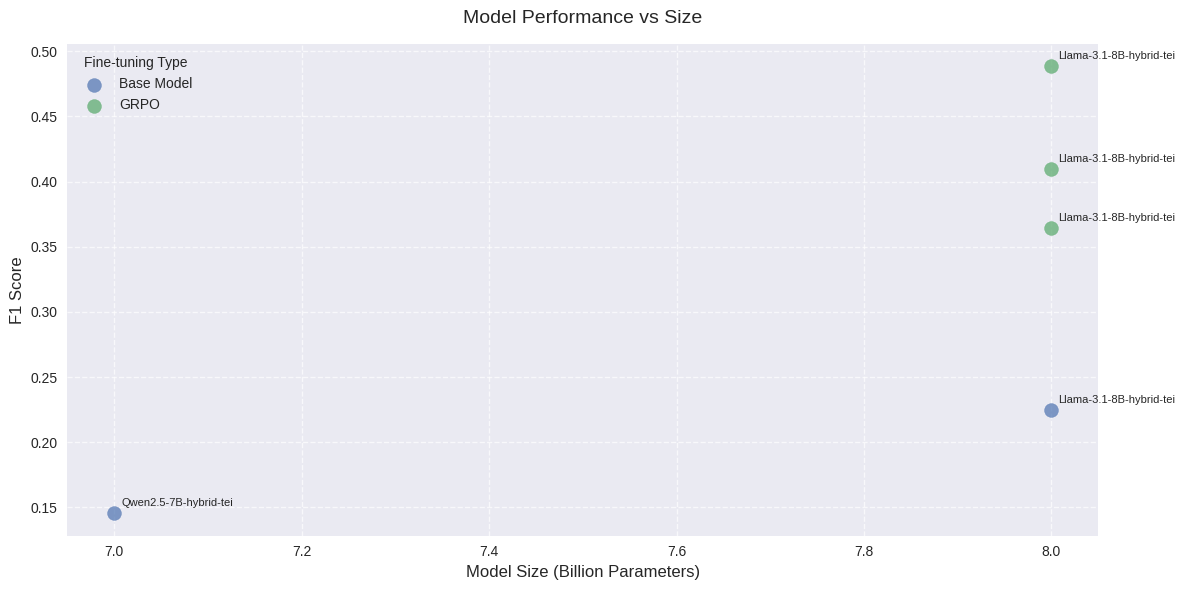

In [10]:
mask = df['params.dataset.path'] == 'bdsaglam/musique'
scatter_plot(df[mask])

In [11]:
# mask = df['params.dataset.path'] == 'bdsaglam/hotpotqa-distractor'
# scatter_plot(df[mask])

In [12]:
def plot_model_size_vs_f1(df):
    """Create a publication-quality scatter plot comparing model size vs F1 score."""
    # Set style and figure size
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

    # Customize appearance
    ax.grid(True, linestyle="--", alpha=0.4, zorder=0)
    ax.set_xlabel("Model Size (Billion Parameters)", fontsize=12, fontweight="bold")
    ax.set_ylabel("F1 Score", fontsize=12, fontweight="bold")
    ax.set_title("Language Model Performance by Parameter Count", fontsize=14, pad=15, fontweight="bold")

    # Set x-axis to logarithmic scale
    ax.set_xscale('log')

    # Define colors and markers
    colors = {"None": "#2E86C1", "GRPO": "#E74C3C"}
    markers = {"None": "o", "GRPO": "^"}

    for fine_tuning in ["None", "GRPO"]:
        mask = df["params.fine_tuning"] == fine_tuning
        label = "Base Model" if fine_tuning == "None" else "GRPO Fine-tuned"

        # Plot points
        ax.scatter(
            df[mask]["params.model.size"],
            df[mask]["metrics.f1"],
            label=label,
            alpha=0.9,
            s=120,
            c=colors[fine_tuning],
            marker=markers[fine_tuning],
            edgecolor="white",
            linewidth=1,
            zorder=2,
        )

        # Add model name annotations
        for idx in df[mask].index:
            label = df.loc[idx, "params.model.base"].replace("Instruct", "").strip("-")
            plt.annotate(
                label,
                (df.loc[idx, "params.model.size"], df.loc[idx, "metrics.f1"]),
                xytext=(7, 7),
                textcoords="offset points",
                fontsize=9,
                alpha=0.8,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1),
            )

    # Customize legend
    ax.legend(title="Model Type", title_fontsize=10, fontsize=10, framealpha=0.9, edgecolor="none", loc="upper left")

    # Set axis limits with padding
    ax.set_xlim(left=1)  # Start at 1B parameters since using log scale
    ax.set_ylim(bottom=0)

    # Format axis ticks
    ax.tick_params(axis="both", which="major", labelsize=10)

    plt.tight_layout()
    plt.show()


In [13]:
def aggregate_best_models(df, by: list[str] = ["params.model.base", "params.fine_tuning"]):
    # Group by model base and fine tuning method
    grouped = df.groupby(by)

    # Get columns of interest
    columns = [
        "params.model.base",
        "params.model.size",
        "params.fine_tuning",
        "params.retriever.name",
        "params.retriever.top_k",
        "params.retriever.mode",
        "metrics.exact_match",
        "metrics.f1",
        "metrics.supporting.recall",
        "metrics.supporting.f1",
    ]

    # For each group, select the row with highest F1 score
    return (
        grouped.apply(lambda x: x.loc[x["metrics.f1"].idxmax()])[columns]
        .reset_index(drop=True)
        .sort_values(by="metrics.f1", ascending=False)
    )

/tmp/ipykernel_3782047/2309424635.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped.apply(lambda x: x.loc[x["metrics.f1"].idxmax()])[columns]


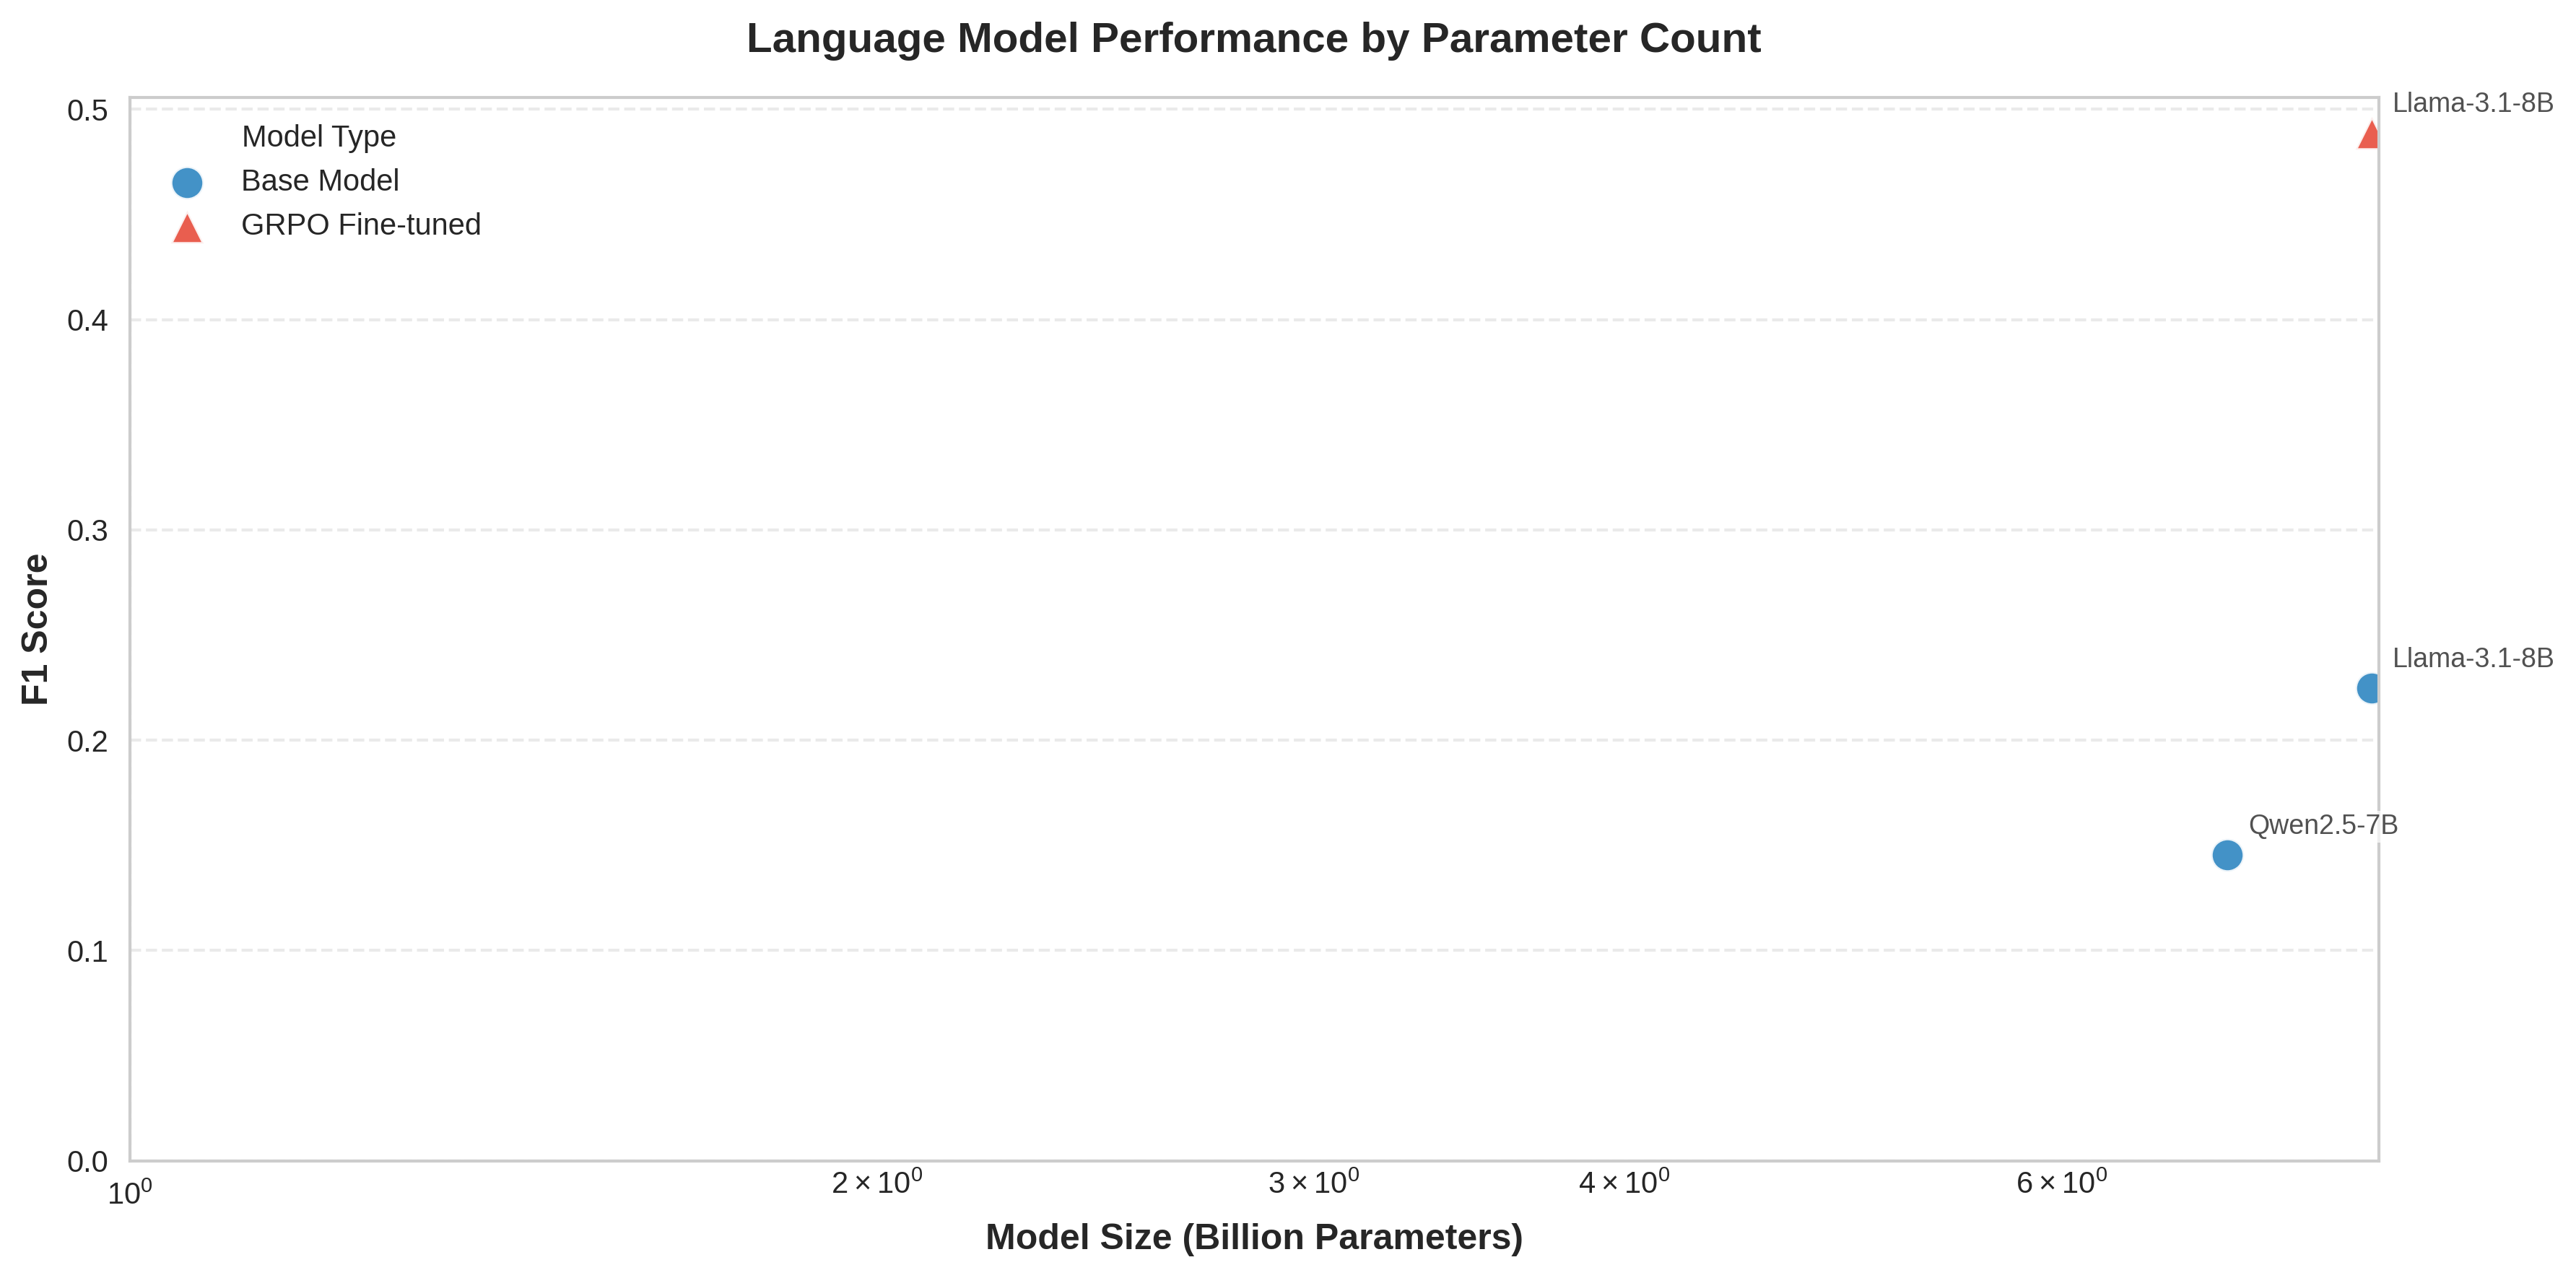

,params.model.base,params.model.size,params.fine_tuning,params.retriever.name,params.retriever.top_k,params.retriever.mode,metrics.exact_match,metrics.f1,metrics.supporting.recall,metrics.supporting.f1
0,Llama-3.1-8B,8.0,GRPO,hybrid-tei,1,new,0.380637,0.488574,0.760723,0.782274
1,Llama-3.1-8B,8.0,None,hybrid-tei,1,new,0.133223,0.224822,0.660495,0.703658
2,Qwen2.5-7B,7.0,None,hybrid-tei,1,new,0.031444,0.145499,0.623259,0.686269


In [14]:
mask = df['params.dataset.path'] == 'bdsaglam/musique'
best_df = aggregate_best_models(df.loc[mask])
plot_model_size_vs_f1(best_df)
display(best_df)